# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [2]:
%pip install -r ./../stellar_classification/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 3.8 MB/s  0:00:04 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 3.7 MB/s  0:00:02m 3.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 1.7 MB/s  0:00:05a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 4.1 MB/s  0:00:02m 4.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 4.1 MB/s  0:00:08 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 17.9 MB/s  0:00:59 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 4.8 MB/s  0:01:00 eta 0:00:010:00:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 3.5 MB/s  0:00:46 eta 0:00:010:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 12.5 MB/s  0:00:15 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.3 MB/s  0:00:04 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import sys
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


20

In [2]:
# Load dataset
data_path = './star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

display(star.head())


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250


/tmp/ipykernel_61585/474802122.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


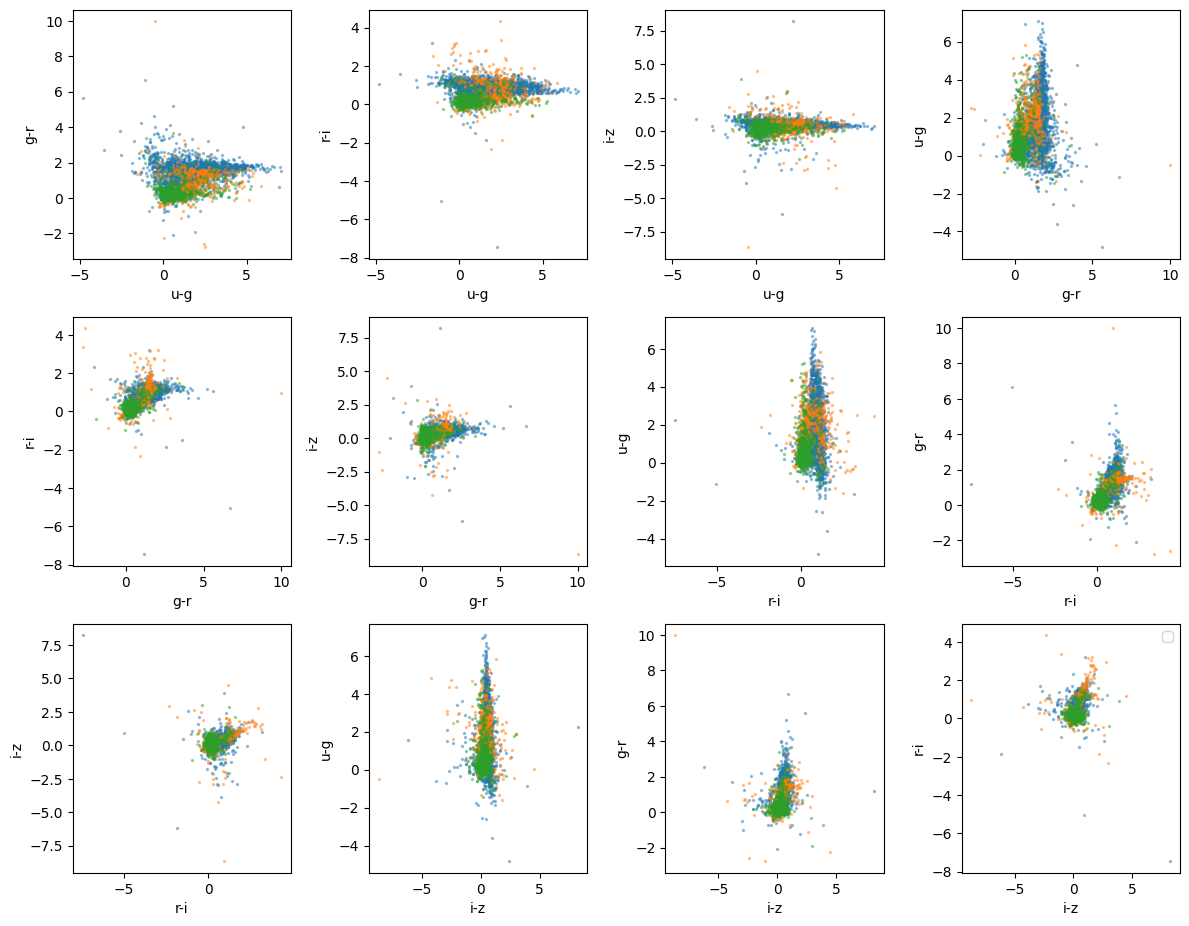

In [ ]:

import itertools

sample = star.sample(5000)

# Color indexes
colors = {
    "u-g": sample["u"] - sample["g"],
    "g-r": sample["g"] - sample["r"],
    "r-i": sample["r"] - sample["i"],
    "i-z": sample["i"] - sample["z"]
}

keys = list(colors.keys())

# color mapping for class
class_colors = {
    "GALAXY": "tab:blue",
    "STAR": "tab:orange",
    "QSO": "tab:green"
}

plt.figure(figsize=(12, 12))

plot_num = 1

for x_key, y_key in itertools.permutations(keys, 2):
    plt.subplot(4, 4, plot_num)

    for cls, color in class_colors.items():
        mask = sample["class"] == cls
        plt.scatter(
            colors[x_key][mask],
            colors[y_key][mask],
            s=2,
            alpha=0.4,
            c=color,
            label=cls if plot_num == 1 else None
        )

    plt.xlabel(x_key)
    plt.ylabel(y_key)
    plot_num += 1

plt.tight_layout()
plt.legend(loc="upper right")
plt.show()

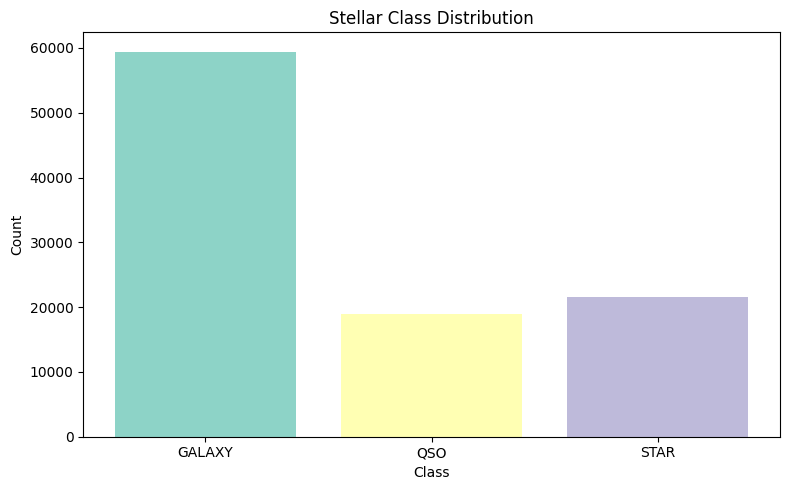

In [3]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


In [3]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
X_train, X_val, X_test, y_train, y_val, y_test, label_encoder, scaler, feature_names = sc.prepare_splits(
    star, 
    target_col='class', 
    test_size=0.2, 
    val_ratio=0.25, 
    random_state=42, 
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


         obj_ID       alpha      delta         u        g         r         i  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573   

          z  run_ID  rerun_ID  ...   spec_obj_ID  class  redshift  plate  \
0  18.79371    3606       301  ...  6.543777e+18      0  0.634794   5812   

     MJD  fiber_ID      u_g      g_r      r_i      i_z  
0  56354       171  1.60352  1.88029  1.22928  0.37202  

[1 rows x 22 columns]
        alpha      delta         u        g         r         i         z  \
0  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573  18.79371   

   class  plate    MJD      u_g      g_r      r_i      i_z  
0      0   5812  56354  1.60352  1.88029  1.22928  0.37202  
Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)


In [4]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)

print("DataLoaders created.")


DataLoaders created.


In [5]:
# Train and evaluate traditional ML models
models = sc.train_traditional(X_train, y_train, X_val, y_val)


Linear SVC trained.
  [Training] Acc=73.09%  P=0.73  R=0.73  F1=0.73
  [Validation] Acc=71.57%  P=0.67  R=0.72  F1=0.69
Decision Tree trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=84.98%  P=0.81  R=0.83  F1=0.82
Random Forest trained.
  [Training] Acc=100.00%  P=1.00  R=1.00  F1=1.00
  [Validation] Acc=90.36%  P=0.88  R=0.88  F1=0.88
CatBoost trained.
  [Training] Acc=93.17%  P=0.93  R=0.93  F1=0.93
  [Validation] Acc=90.23%  P=0.87  R=0.88  F1=0.87
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
LightGBM trained.


/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [Training] Acc=91.31%  P=0.91  R=0.91  F1=0.91
  [Validation] Acc=90.05%  P=0.87  R=0.88  F1=0.87


/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [6]:
# Train Voting Classifier utilizing the trained models
voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001329 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 97032, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Voting Classifier trained.


/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  [Training] Acc=95.55%  P=0.96  R=0.96  F1=0.96
  [Validation] Acc=90.40%  P=0.88  R=0.88  F1=0.88


/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [7]:
# Train PyTorch Neural Network
input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

nn_model = sc.train_neural(
    train_loader=train_loader,
    val_loader=val_loader,
    input_size=input_size,
    num_classes=num_classes,
    num_epochs=10,
    lr=0.001
)


Epoch  1/10  loss=0.4915  val_acc=85.92%
Epoch  2/10  loss=0.4176  val_acc=85.98%
Epoch  3/10  loss=0.3976  val_acc=86.63%
Epoch  4/10  loss=0.3852  val_acc=87.01%
Epoch  5/10  loss=0.3757  val_acc=87.79%
Epoch  6/10  loss=0.3687  val_acc=85.18%
Epoch  7/10  loss=0.3628  val_acc=86.68%
Epoch  8/10  loss=0.3574  val_acc=87.52%
Epoch  9/10  loss=0.3533  val_acc=87.66%
Epoch 10/10  loss=0.3490  val_acc=87.71%


In [8]:
# Base inference on test set
import torch 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

nn_metrics = sc.evaluate_neural(test_loader, nn_model, device, "Neural Network")
sc.print_metrics(nn_metrics)


/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Voting Classifier:
  Accuracy  : 90.75%
  Precision: 0.8800
  Recall   : 0.8844
  F1       : 0.8814
  Confusion Matrix:
[[10194   362   225]
 [  218  3113   217]
 [  279   388  3261]]

Neural Network:
  Accuracy  : 88.20%
  Precision: 0.8466
  Recall   : 0.8610
  F1       : 0.8525
  Confusion Matrix:
[[9891  473  417]
 [ 220 3093  235]
 [ 340  470 3118]]


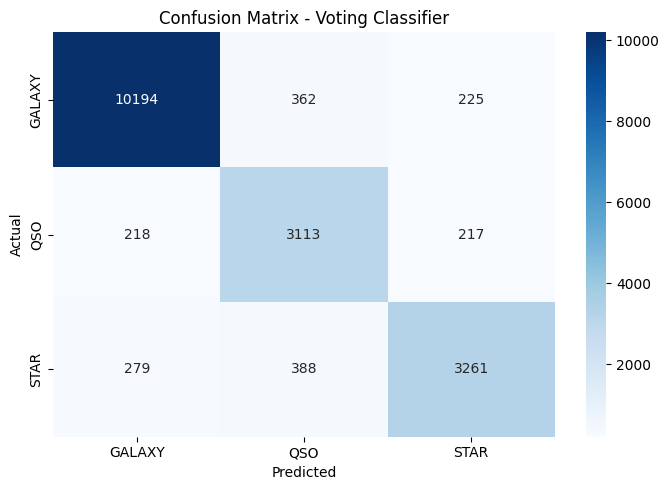

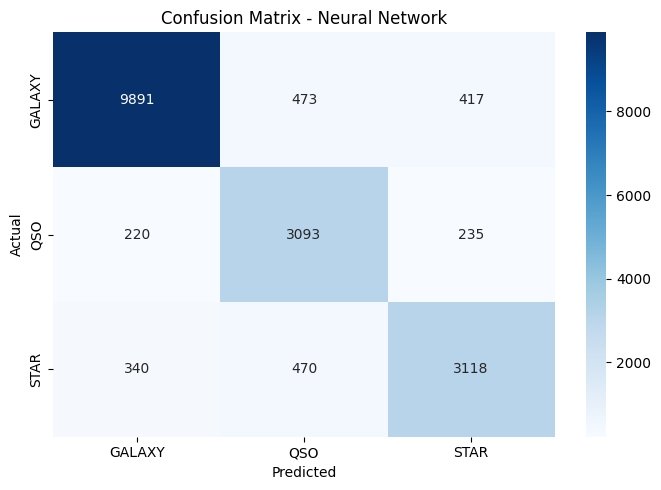

In [9]:
# Confusion Matrices
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier')
sc.plot_confusion_matrix(nn_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Neural Network')


In [16]:
import importlib

importlib.reload(sc)

<module 'stellar_classification' from '/home/ettore/Scrivania/Magistrale/LCP_B/Progetto_LCPB/Computational-Physics-2026/Astrophysical-Objects-Recognition/stellar_classification/stellar_classification/__init__.py'>

1 batch shape: 4000


/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

2 batch shape: 4000


/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

3 batch shape: 4000


/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

4 batch shape: 4000


/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

5 batch shape: 2257


/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not ha

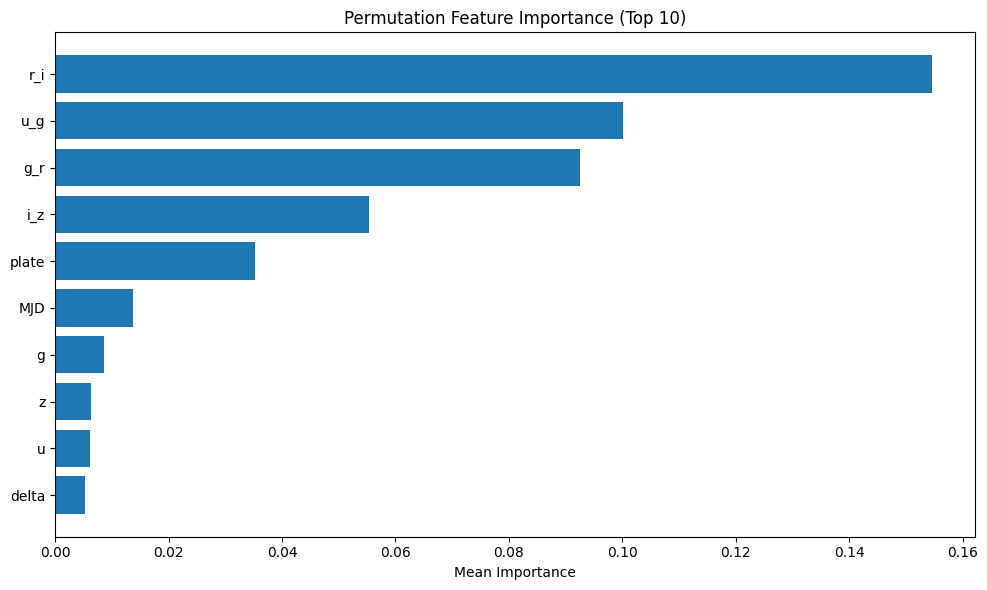

Feature Importance Scores:
r_i: 0.1545
u_g: 0.1001
g_r: 0.0926
i_z: 0.0553
plate: 0.0353
MJD: 0.0137
g: 0.0087
z: 0.0063
u: 0.0061
delta: 0.0053
alpha: 0.0045
i: 0.0041
r: 0.0032


In [10]:
# Feature Importance (using permutation importance on the Voting Classifier)
#n_jobs decide quanti core usare, parti da 1 e monitora la ram, aumentalo un po alla volta (con 16 GB non oltre n_jobs=3)
#n_jobs è un parametro di permutation_importance di scikit-learn, leggete 
#la doc, non mettete n_jobs=-1 !!!!!!
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=1)
sc.plot_permutation_importance(imp, top_n=10)

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")
